In [ ]:
import dask
from dask.distributed import Client
import os

scheduler_file = os.path.join(os.environ["SCRATCH"], "scheduler_file.json")

client = Client(scheduler_file=scheduler_file)
client

<Client: 'tcp://10.249.1.93:8786' processes=32 threads=8192, memory=14.89 TiB>

2026-05-27 02:43:28,066 - distributed.client - ERROR - Failed to reconnect to scheduler after 30.00 seconds, closing client


In [2]:
import xarray as xr
import sys
import time
import xpartition  # noqa
from xtorch_harmonics import roundtrip_filter
sys.path.append("/pscratch/sd/e/elynnwu/ace/scripts/data_process")
from time_utils import shift_timestamps_to_midpoint

In [3]:
time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)

In [4]:
RUN_DIR = "/global/cfs/cdirs/e3smdata/simulations/v3.LR.piControl.aigo/run"

#### Ocean

In [5]:
ds_mpas_df = xr.open_mfdataset(f"{RUN_DIR}/*am*fmeDerivedFields5D*remapped.nc", \
    decode_times=time_coder, \
    combine="nested", \
    concat_dim="time", \
    join="override", \
    data_vars="minimal",\
    coords="minimal",\
    compat="override")

ds_mpas_dc = xr.open_mfdataset(f"{RUN_DIR}/*am*fmeDepthCoarsening5D*remapped.nc", \
    decode_times=time_coder, \
    combine="nested", \
    concat_dim="time", \
    join="override", \
    data_vars="minimal",\
    coords="minimal",\
    compat="override")
ds_mpas_dc = ds_mpas_dc.assign_coords({"lat": ds_mpas_df.lat, "lon": ds_mpas_df.lon})

ds_mpas_sic = xr.open_mfdataset(f"{RUN_DIR}/*am*fmeSeaiceDerivedFields5D*remapped.nc", \
    decode_times=time_coder, \
    combine="nested", \
    concat_dim="time", \
    join="override", \
    data_vars="minimal",\
    coords="minimal",\
    compat="override")
ds_mpas_sic = ds_mpas_sic.assign_coords({"lat": ds_mpas_df.lat, "lon": ds_mpas_df.lon})

ds_mpas = xr.merge([ds_mpas_df, ds_mpas_dc, ds_mpas_sic])

/tmp/ipykernel_1466901/3989355048.py:30: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  ds_mpas = xr.merge([ds_mpas_df, ds_mpas_dc, ds_mpas_sic])
/tmp/ipykernel_1466901/3989355048.py:30: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  ds_mpas = xr.merge([ds_mpas_df, ds_mpas_dc, ds_mpas_sic])
/tmp/ipykernel_1466901/3989355048.py:30: Futur

In [6]:
ds_mpas.time_bnds.isel(time=0).values

array([cftime.DatetimeNoLeap(401, 1, 1, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(401, 1, 6, 0, 0, 0, 0, has_year_zero=True)],
      dtype=object)

In [7]:
ds_mpas.time.isel(time=0).values

array(cftime.DatetimeNoLeap(401, 1, 6, 0, 0, 0, 0, has_year_zero=True),
      dtype=object)

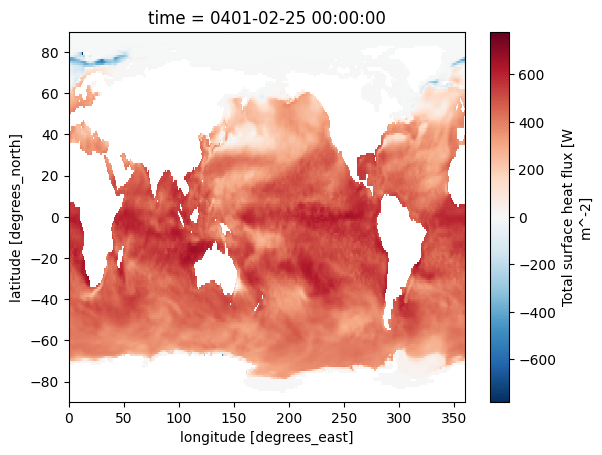

In [8]:
ds_mpas.surfaceHeatFluxTotal.isel(time=10).plot()

In [9]:
DROP_VARS = ["date", "datesec", "time_bnds"]
DROP_PATTERNS = [v for v in ds_mpas.data_vars if v.startswith("layerThicknessCoarsened_")]
ds_mpas = ds_mpas.drop_vars(DROP_VARS + DROP_PATTERNS)

In [10]:
ds_mpas["sst"] = ds_mpas["sst"] + 273.15
ds_mpas["sst"].attrs["units"] = "K"
ds_mpas = shift_timestamps_to_midpoint(ds_mpas, time_dim="time")
ds_mpas["time"].attrs["long_name"] = "time, avg interval midpoint"
chunks = {"time": 60, "lat": -1, "lon": -1}
ds_mpas = ds_mpas.chunk(chunks)

In [ ]:
output = "/pscratch/sd/e/elynnwu/fme-dataset/2026-05-26-E3SMv3-piControl-ocean-100yr-5D-average.zarr"
n_split = 50
inner_chunks = {"time": 1, "lat": -1, "lon": -1}
ds_mpas.partition.initialize_store(output, inner_chunks=inner_chunks)
for i in range(n_split):
    segment_number = f"{i + 1} / 50"
    print(f"Writing segment {segment_number}")
    segment_time = time.time()
    ds_mpas.partition.write(
        output,
        n_split,
        ["time"],
        i,
        collect_variable_writes=True,
    )
    segment_time = time.time() - segment_time
    print(f"Segment {segment_number} time: {segment_time:0.2f} seconds")

In [14]:
DIMS = ["time", "lat", "lon"]

START_DATE = "0401-01-01 00:00:00"
END_DATE = "0500-01-01 00:00:00"

STATS_DIR = f"/pscratch/sd/e/elynnwu/fme-dataset/2026-05-26-E3SMv3-piControl-ocean-100yr-5D-average-stats"

if not os.path.isdir(STATS_DIR):
    os.makedirs(STATS_DIR)

In [15]:
print("Centering")
centering = ds_mpas.mean(dim=DIMS).compute()
print("Scaling full field")
scaling_full_field = ds_mpas.std(dim=DIMS).compute()
print("Scaling residual")
scaling_residual = ds_mpas.diff("time").std(dim=DIMS).compute()
print("Computing time means")
time_means = ds_mpas.mean(dim="time").compute()

def add_history_attrs(ds_mpas, input_zarr, start_date, end_date, n_samples):
    ds_mpas.attrs["history"] = (
        f"Created by explore2/elynn/2026-05-26-E3SMv3-piControl-v202605-preprocess.ipynb. INPUT_ZARR:"
        f" {input_zarr}, START_DATE: {start_date}, END_DATE: {end_date}."
    )
    ds_mpas.attrs["input_samples"] = n_samples

for dataset in [
    centering,
    scaling_full_field,
    scaling_residual,
    time_means,
]:
    n_samples = len(ds_mpas.time)
    add_history_attrs(
        dataset,
        "/pscratch/sd/e/elynnwu/fme-dataset/2026-05-26-E3SMv3-piControl-v202605-preprocess.zarr",
        START_DATE,
        END_DATE,
        n_samples,
    )
centering.to_netcdf(os.path.join(STATS_DIR, "centering.nc"))
scaling_full_field.to_netcdf(os.path.join(STATS_DIR, "scaling-full-field.nc"))
scaling_residual.to_netcdf(os.path.join(STATS_DIR, "scaling-residual.nc"))
time_means.to_netcdf(os.path.join(STATS_DIR, "time-mean.nc"))

Centering


/pscratch/sd/e/elynnwu/conda-venv/fme-preprocess/lib/python3.11/site-packages/distributed/client.py:3375: UserWarning: Sending large graph of size 167.32 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


Scaling full field


/pscratch/sd/e/elynnwu/conda-venv/fme-preprocess/lib/python3.11/site-packages/distributed/client.py:3375: UserWarning: Sending large graph of size 167.36 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


Scaling residual


/pscratch/sd/e/elynnwu/conda-venv/fme-preprocess/lib/python3.11/site-packages/distributed/client.py:3375: UserWarning: Sending large graph of size 175.75 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


Computing time means


/pscratch/sd/e/elynnwu/conda-venv/fme-preprocess/lib/python3.11/site-packages/distributed/client.py:3375: UserWarning: Sending large graph of size 166.76 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


In [16]:
client.close()

In [17]:
ds_mpas.time

<xarray.DataArray 'time' (time: 7317)> Size: 59kB
array([cftime.DatetimeNoLeap(401, 1, 3, 12, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(401, 1, 8, 12, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(401, 1, 13, 12, 0, 0, 0, has_year_zero=True), ...,
       cftime.DatetimeNoLeap(501, 3, 14, 12, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(501, 3, 19, 12, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(501, 3, 24, 12, 0, 0, 0, has_year_zero=True)],
      shape=(7317,), dtype=object)
Coordinates:
  * time     (time) object 59kB 0401-01-03 12:00:00 ... 0501-03-24 12:00:00
Attributes:
    long_name:  time, avg interval midpoint
    bounds:     time_bnds
    axis:       T

### Atmosphere

In [6]:
ds_eam = xr.open_mfdataset(f"{RUN_DIR}/*eam.h0.*.nc", \
    decode_times=time_coder, \
    combine="nested", \
    concat_dim="time", \
    join="override", \
    data_vars="minimal",\
    coords="minimal",\
    compat="override")

In [8]:
DROP_VARS = ["ndbase", "nsbase", "nbdate", "nbsec", "mdt"]
for var in ds_eam.data_vars:
    if "nbnd" in ds_eam[var].dims or "lev" in ds_eam[var].dims or "ilev" in ds_eam[var].dims:
        DROP_VARS.append(var)
    if ds_eam[var].dims == ("time",):
        DROP_VARS.append(var)

DROP_PATTERNS = [v for v in ds_eam.data_vars if v.startswith("Q_")]
ds_eam = ds_eam.drop_vars(DROP_VARS + DROP_PATTERNS, errors="ignore")

drop_coords = [c for c in ds_eam.coords if c not in ["lat", "lon", "time"]]
ds_eam = ds_eam.drop_vars(drop_coords, errors="ignore")

In [10]:
ROUNDTRIP_VARS = [v for v in ds_eam.data_vars if v.startswith(("T_", "STW_", "U_", "V_"))]
ROUNDTRIP_VARS += ["PS", "TS"]

ds_filtered = ds_eam[ROUNDTRIP_VARS]
ds_unfilterd = ds_eam.drop_vars(ROUNDTRIP_VARS)
ds_filtered = roundtrip_filter(
    ds_filtered,
    lat_dim="lat",
    lon_dim="lon",
    fraction_modes_kept=1.0,
)
ds_eam = xr.merge([ds_filtered, ds_unfilterd])

In [11]:
LIQUID_PRECIP_DENSITY = 1e3  # kg/m**3
ds_eam["surface_precipitation_rate"] = ds_eam["PRECT"] * LIQUID_PRECIP_DENSITY
ds_eam["frozen_precipitation_rate"] = ds_eam["PRECST"] * LIQUID_PRECIP_DENSITY
ds_eam = ds_eam.drop_vars(["PRECT", "PRECST"])

In [12]:
ds_eam["LANDFRAC"] = ds_eam["LANDFRAC"].isel(time=0)
ds_eam["PHIS"] = ds_eam["PHIS"].isel(time=0)

In [14]:
chunks = {"time": 360, "lat": -1, "lon": -1}
ds_eam = ds_eam.chunk(chunks)
print(f"Output dataset size is {ds_eam.nbytes / 1e9} GB")

Output dataset size is 2314.113114544 GB


In [15]:
output = "/pscratch/sd/e/elynnwu/fme-dataset/2026-05-26-E3SMv3-piControl-atmosphere-100yr-6H.zarr"
n_split = 100
inner_chunks = {"time": 1, "lat": -1, "lon": -1}
ds_eam.partition.initialize_store(output, inner_chunks=inner_chunks)
for i in range(n_split):
    segment_number = f"{i + 1} / 100"
    print(f"Writing segment {segment_number}")
    segment_time = time.time()
    ds_eam.partition.write(
        output,
        n_split,
        ["time"],
        i,
        collect_variable_writes=True,
    )
    segment_time = time.time() - segment_time
    print(f"Segment {segment_number} time: {segment_time:0.2f} seconds")

/pscratch/sd/e/elynnwu/conda-venv/fme-preprocess/lib/python3.11/site-packages/zarr/api/asynchronous.py:247: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


Writing segment 1 / 100


/pscratch/sd/e/elynnwu/conda-venv/fme-preprocess/lib/python3.11/site-packages/distributed/client.py:3375: UserWarning: Sending large graph of size 106.01 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


Segment 1 / 100 time: 67.98 seconds
Writing segment 2 / 100


/pscratch/sd/e/elynnwu/conda-venv/fme-preprocess/lib/python3.11/site-packages/distributed/client.py:3375: UserWarning: Sending large graph of size 106.01 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


...

Segment 80 / 100 time: 80.25 seconds
Writing segment 81 / 100


/pscratch/sd/e/elynnwu/conda-venv/fme-preprocess/lib/python3.11/site-packages/distributed/client.py:3375: UserWarning: Sending large graph of size 106.01 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


Segment 81 / 100 time: 68.57 seconds
Writing segment 82 / 100


/pscratch/sd/e/elynnwu/conda-venv/fme-preprocess/lib/python3.11/site-packages/distributed/client.py:3375: UserWarning: Sending large graph of size 105.98 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


Segment 82 / 100 time: 57.77 seconds
Writing segment 83 / 100
Segment 83 / 100 time: 0.28 seconds
Writing segment 84 / 100
Segment 84 / 100 time: 0.26 seconds
Writing segment 85 / 100
Segment 85 / 100 time: 0.29 seconds
Writing segment 86 / 100
Segment 86 / 100 time: 0.24 seconds
Writing segment 87 / 100
Segment 87 / 100 time: 0.25 seconds
Writing segment 88 / 100
Segment 88 / 100 time: 0.24 seconds
Writing segment 89 / 100
Segment 89 / 100 time: 0.24 seconds
Writing segment 90 / 100
Segment 90 / 100 time: 0.24 seconds
Writing segment 91 / 100
Segment 91 / 100 time: 0.24 seconds
Writing segment 92 / 100
Segment 92 / 100 time: 0.26 seconds
Writing segment 93 / 100
Segment 93 / 100 time: 0.26 seconds
Writing segment 94 / 100
Segment 94 / 100 time: 0.27 seconds
Writing segment 95 / 100
Segment 95 / 100 time: 0.32 seconds
Writing segment 96 / 100
Segment 96 / 100 time: 0.33 seconds
Writing segment 97 / 100
Segment 97 / 100 time: 0.32 seconds
Writing segment 98 / 100
Segment 98 / 100 time: 

In [16]:
DIMS = ["time", "lat", "lon"]

START_DATE = "0401-01-01 00:00:00"
END_DATE = "0500-01-01 00:00:00"

STATS_DIR = f"/pscratch/sd/e/elynnwu/fme-dataset/2026-05-26-E3SMv3-piControl-atmosphere-100yr-6H-stats"

if not os.path.isdir(STATS_DIR):
    os.makedirs(STATS_DIR)

In [ ]:
print("Centering")
centering = ds_eam.mean(dim=DIMS).compute()
print("Scaling full field")
scaling_full_field = ds_eam.std(dim=DIMS).compute()
print("Scaling residual")
scaling_residual = ds_eam.diff("time").std(dim=DIMS).compute()
print("Computing time means")
time_means = ds_eam.mean(dim="time").compute()

def add_history_attrs(ds_eam, input_zarr, start_date, end_date, n_samples):
    ds_eam.attrs["history"] = (
        f"Created by explore2/elynn/2026-05-26-E3SMv3-piControl-v202605-preprocess.ipynb. INPUT_ZARR:"
        f" {input_zarr}, START_DATE: {start_date}, END_DATE: {end_date}."
    )
    ds_eam.attrs["input_samples"] = n_samples

for dataset in [
    centering,
    scaling_full_field,
    scaling_residual,
    time_means,
]:
    n_samples = len(ds_eam.time)
    add_history_attrs(
        dataset,
        "/pscratch/sd/e/elynnwu/fme-dataset/2026-05-26-E3SMv3-piControl-atmosphere-100yr-6H.zarr",
        START_DATE,
        END_DATE,
        n_samples,
    )
centering.to_netcdf(os.path.join(STATS_DIR, "centering.nc"))
scaling_full_field.to_netcdf(os.path.join(STATS_DIR, "scaling-full-field.nc"))
scaling_residual.to_netcdf(os.path.join(STATS_DIR, "scaling-residual.nc"))
time_means.to_netcdf(os.path.join(STATS_DIR, "time-mean.nc"))

In [18]:
centering.to_netcdf(os.path.join(STATS_DIR, "centering.nc"))
scaling_full_field.to_netcdf(os.path.join(STATS_DIR, "scaling-full-field.nc"))
scaling_residual.to_netcdf(os.path.join(STATS_DIR, "scaling-residual.nc"))